# Image EDA

In [2]:
path = "/Users/jiaxiliu/Desktop/CS1090B/cs1090b_project/ds_cleaned_hf/"

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "arrow",
    data_files={
        "train": [
            path + "data-00000-of-00005.arrow",
            path + "data-00001-of-00005.arrow",
            path + "data-00002-of-00005.arrow",
            path + "data-00003-of-00005.arrow",
            path + "data-00004-of-00005.arrow",
        ]
    }
)

data = dataset["train"]

/Users/jiaxiliu/anaconda3/envs/cs1090b_hw2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Sample Visualization

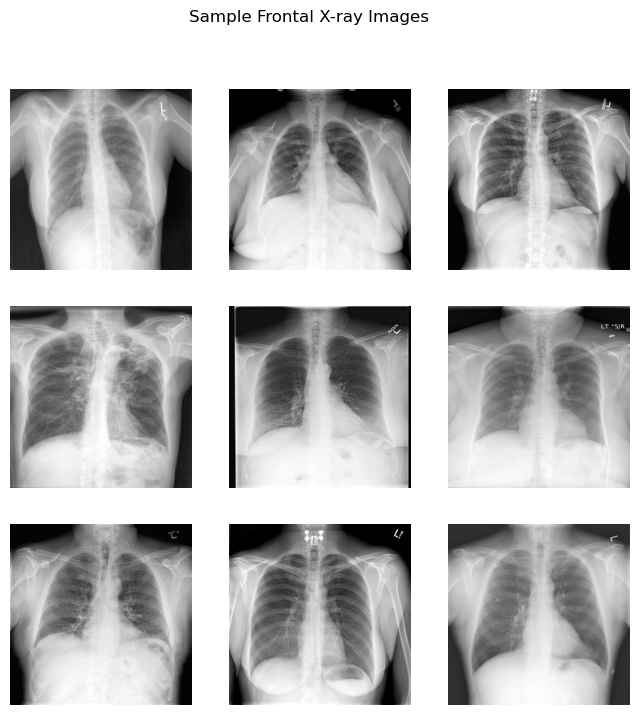

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = data[i]["img_frontal_processed"]
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Sample Frontal X-ray Images")
plt.show()

The sample frontal X-ray images show consistent anatomical structures, including clear lung fields, rib boundaries, and heart silhouettes.

There is visible variability across samples, with some images showing potential abnormalities such as opacities or asymmetry, suggesting the dataset contains both normal and pathological cases.

The images are centered and aligned, indicating successful preprocessing and suitability for downstream modeling.

In [7]:
sizes = []

for i in range(len(data)):
    img = data[i]["img_frontal_processed"]
    sizes.append(img.size)

set(sizes)

{(224, 224)}

##  Pixel Intensity Distribution

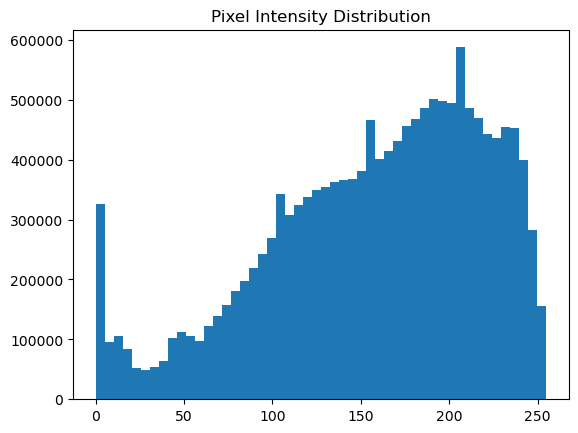

In [9]:
import numpy as np

pixels = []

for i in range(100):
    img = np.array(data[i]["img_frontal_processed"])
    pixels.extend(img.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

The pixel intensity distribution spans the full grayscale range (0–255), indicating that the images preserve sufficient contrast information.

The distribution is skewed toward higher intensity values, which is expected in chest X-rays due to large bright regions such as bones and background areas.

The absence of extreme spikes or degenerate distributions suggests that the images are not corrupted and have been properly normalized.

In [11]:
means = []
for i in range(100):
    img = np.array(data[i]["img_frontal_processed"])
    means.append(img.mean())

print(np.mean(means), np.std(means))

158.0097532684949 16.440003014495094


The average pixel intensity across sampled images is approximately 158 with a standard deviation of 16.4.

The relatively high mean intensity reflects the presence of bright regions such as bones and background in chest X-ray images.

The low standard deviation suggests that pixel intensity is consistent across samples, indicating stable preprocessing and uniform image quality.

This consistency is beneficial for model training, suggesting that the dataset is well-normalized, as it reduces variability unrelated to underlying pathology.

## Multi-view Comparison

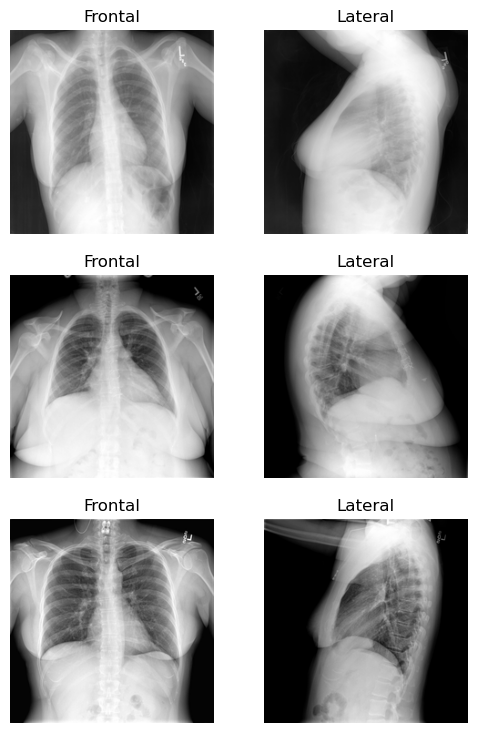

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i in range(3):
    axes[i, 0].imshow(data[i]["img_frontal_processed"])
    axes[i, 0].set_title("Frontal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(data[i]["img_lateral_processed"])
    axes[i, 1].set_title("Lateral")
    axes[i, 1].axis("off")

plt.show()

Each sample contains both frontal and lateral views, providing complementary perspectives of the chest.

While frontal images capture the overall lung structure, lateral views provide additional depth information that may help identify abnormalities not visible in a single view.

This multi-view setup suggests potential for multimodal or multi-input modeling approaches.

## Summary

Overall, the image data appears clean, standardized, and suitable for CNN-based modeling, with sufficient variability to capture clinically relevant patterns.